# Binning tool

This notebook is a walkthrough for the pipeline used by the binning reconstruction code

In [1]:
import sys
import pprint
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from copy    import deepcopy
from time    import time
from tqdm    import tqdm

from getdist import plots,MCSamples

#Plotting
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import rc


rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

In [2]:
possible_derivatives = ['f','int','d1','d2']

# Preliminaries

Some things to do at the beginning so that we can enjoy a wonderful GP experience

## Settings

Here we specify the fixed settings of the reconstruction, namely the number and distribution of the $x$ points where the reconstruction is performed

In [3]:
N_recon    = 5
xmin_recon = 0.1
xmax_recon = 1.8
x_recon = np.linspace(xmin_recon,xmax_recon,N_recon)

## Theoretical function

In [4]:
def get_theory(coeffs):

    from numpy.polynomial import Polynomial
    
    p = Polynomial(coeffs)
    # Compute derivatives and integral using NumPy's built-in methods
    p_deriv1 = p.deriv(m=1)   # First derivative
    p_deriv2 = p.deriv(m=2)   # Second derivative
    p_integ  = p.integ(m=1)   # Antiderivative (integration constant C=0)
    results = {'f': lambda x: p(x),
               'd1': lambda x: p_deriv1(x),
               'd2': lambda x: p_deriv2(x),
               'int': lambda x: p_integ(x)}
    return results

## Create data to be reconstructed

Here we simulate data and errors for a completely made up observable

$$f(x) = \sum_{i=0}^N{a_ix^i}$$

where $N$ is the order of the polynomial and $a_i$ are the parameters controlling the $x$ trend of the observable

### Data settings

Settings controlling the data quality: number of measurements and their error

In [5]:
Ndata   = 100
xmin    = 0
xmax    = 2
err_fac = 5

x_label = r'$x$'
y_label = r'$f(x)$'

### Theory model

In [6]:
fiducial = {'a0': 3,
            'a1': -1,
            'a2': 5,
            'a3': -0.1
           }

theory_model = get_theory(list(fiducial.values()))

### Data generation

In [7]:
dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})

thvals = theory_model['f'](dataset['x'])
errors = abs(thvals)*err_fac/100
dataset['f'] = np.random.normal(thvals,errors)
dataset['f_err'] = errors

covmat = pd.DataFrame(np.diag(errors*2),columns=['f_{}'.format(ind) for ind in range(len(dataset['x']))])
covmat.index = covmat.columns

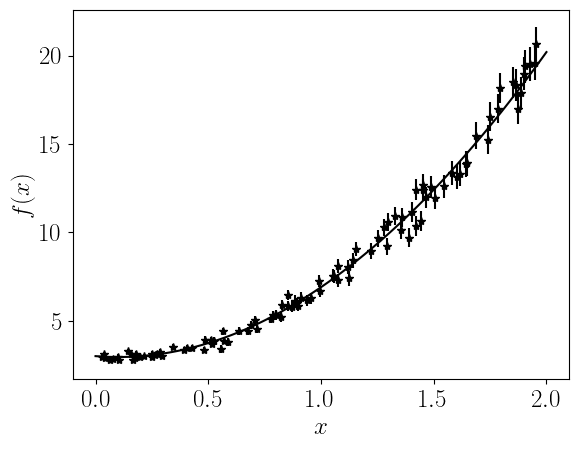

In [8]:
xplot = np.linspace(xmin,xmax,100)
plt.figure()
plt.plot(xplot,theory_model['f'](xplot),color='black')
plt.errorbar(dataset['x'],dataset['f'],yerr=dataset['f_err'],color='black',ls='',marker='*')
plt.xlabel(x_label)
plt.ylabel(y_label);

# Binning

**WRITE WHY WE DO THIS**

## The binning class: BinnedCalculator

**EXPLAIN THE CLASS**

In [9]:
from CoRe.reconstruction_tools.Binning import BinnedCalculator

## 1) Binning data

The first step is to reduce the data in the $x$ values of interest

In [10]:
binning_results = {}
methods = []
colors = [red,yellow]

### 1.1) Flat binning

The binning framework implements an optimal data compression scheme based on Generalized Least Squares (GLS). Instead of executing a localized averaging of data points, this method acts on flattened residuals to preserve the maximal  information when condensing a highly correlated dataset.

**Step 1: Fiducial Flattening (Residual Space)**

Given an uncompressed dataset containing coordinates $\mathbf{x}_{\text{old}}$, a mean function vector $\mathbf{f}_{\text{old}}$, and an $N_{\text{old}} \times N_{\text{old}}$ covariance matrix $C_{\text{old}}$, the data is first transformed into dimensionless residuals using a continuous fiducial baseline function $f_{\text{fid}}(x)$:
\begin{equation}
\mathbf{y}_{\text{old}} = \mathbf{f}_{\text{old}} / f_{\text{fid}}(\mathbf{x}_{\text{old}})
\end{equation}
where the division is element-wise. The original covariance matrix is subsequently projected into residual space via a transformation:
\begin{equation}
C_{y,\text{old}} = G_{\text{old}} \, C_{\text{old}} \, G_{\text{old}}^T
\end{equation}
where $G_{\text{old}}$ is a diagonal matrix containing the scaling weights: $G_{\text{old}, ii} = 1 / f_{\text{fid}}(x_{\text{old}, i})$.

**Step 2: Linear Mapping Operator**

A target grid layout of binned centers $\mathbf{x}_{\text{new}}$ is defined, and midpoints are used to establish strict bounding edges. A binary indicator or design matrix $A$ of size $N_{\text{old}} \times N_{\text{new}}$ is generated to map uncompressed coordinates to their respective spatial bins:
\begin{equation}
A_{ij} = \begin{cases} 
1.0 & \text{if } x_{\text{old}, i} \in \text{Bin } j \\
0.0 & \text{otherwise}
\end{cases}
\end{equation}

**Step 3: Minimum-Variance Compression**

Assuming that the residual field $\mathbf{y}$ is approximately constant (flat) within the boundaries of each individual bin, the minimum-variance binned covariance $C_{y,\text{new}}$ and binned residual mean vector $\mathbf{y}_{\text{new}}$ are solved analytically using the inverse covariance as a statistical weight:
\begin{equation}
C_{y,\text{new}} = \left( A^T C_{y,\text{old}}^{-1} A \right)^{-1}
\end{equation}
\begin{equation}
\mathbf{y}_{\text{new}} = C_{y,\text{new}} \, A^T C_{y,\text{old}}^{-1} \, \mathbf{y}_{\text{old}}
\end{equation}
This formulation naturally down-weights redundant statistical information arising from highly auto-correlated adjacent points.

**Step 4: Back-Projection to Physical Space**

Finally, the compressed configuration is un-flattened back into physical units at the new target coordinate sites $\mathbf{x}_{\text{new}}$:
\begin{equation}
\mathbf{f}_{\text{new}} = \mathbf{y}_{\text{new}}  f_{\text{fid}}(\mathbf{x}_{\text{new}})
\end{equation}
\begin{equation}
C_{\text{new}} = G_{\text{new}} \, C_{y,\text{new}} \, G_{\text{new}}^T
\end{equation}
where the vector multiplications is element-wise, and $G_{\text{new}}$ is the physical re-scaling diagonal matrix defined by $G_{\text{new}, jj} = f_{\text{fid}}(x_{\text{new}, j})$.


**WARNING: All this thing might explode if one bin is empty**

In [11]:
bin_engine = BinnedCalculator(dataset,covmat,method='FLAT')
f_new,C_new,mask = bin_engine.flat_residual_binning(x_recon,fiducial=theory_model['f'])
binning_results['FLAT'] = {'f': f_new,
                           'mask': mask,
                           'covmat': C_new,
                           'class': bin_engine}

print(mask)
methods = methods + ['FLAT']

[ True  True  True  True  True]


### Checking flat binning residual

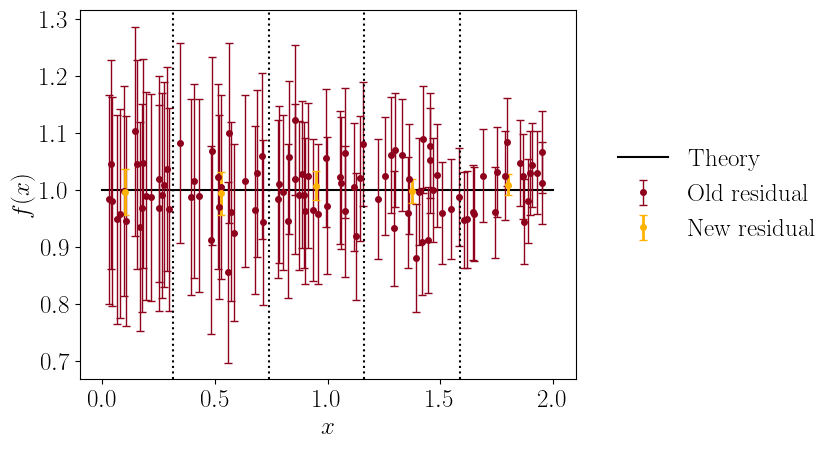

In [12]:
if 'FLAT' in binning_results:
    plt.figure()
    plt.plot(xplot,[1]*len(xplot),color='black',label='Theory')
    plt.xlabel(r'$x$')
    plt.ylabel(r'$f(x)$')
    
    inner = binning_results['FLAT']['class']
    plt.errorbar(inner.x_old,inner.residual_old,yerr=np.sqrt(np.diag(inner.C_residual_old)),ls='',
                 fmt='o',ms=4,capsize=3,elinewidth=1.0,label='Old residual',color=red)
    plt.errorbar(inner.x_valid,inner.residual_new,yerr=np.sqrt(np.diag(inner.C_residual_new)),ls='',
                 fmt='o',ms=4,capsize=3,elinewidth=2.0,label='New residual',color=yellow)
    for edge in inner.bin_edges:
        plt.axvline(x=edge,ls=':',color='black')
    
    plt.legend(**sidelegend);

### 1.2) GLS binning

In [13]:
bin_engine = BinnedCalculator(dataset,covmat,method='GLS')
f_new,C_new,mask = bin_engine.GLS_binning(x_recon,tol=1.e-2,max_iter=50)
binning_results['GLS'] = {'f': f_new,
                          'mask': mask,
                          'covmat': C_new,
                          'class': bin_engine}

methods = methods + ['GLS']

  [value] well-covered bins: [0, 1, 2, 3, 4]
  [value] edge optimization converged at iter 5  (max |x_eff - x_new| = 6.66e-03)


## 2) Get derivatives

For an unevenly spaced grid $\mathbf{x} = [x_0, x_1, \dots, x_{N-1}]^T$, let the local forward and backward step sizes for an interior point $i$ be defined as $h_+ = x_{i+1} - x_i$ and $h_- = x_i - x_{i-1}$ respectively.

**First Derivative Operator ($D_1$)**

The first derivative of a discrete function $\mathbf{f}$ at any interior node $i$ ($0 < i < N-1$) is evaluated using a 3-point central finite difference stencil optimized for non-uniform spacing:
\begin{equation}
f'(x_i) \approx a_i f(x_{i-1}) + b_i f(x_i) + c_i f(x_{i+1})
\end{equation}
where the weighting coefficients derived via Taylor expansions are:
\begin{equation}
a_i = \frac{-h_+}{h_-(h_- + h_+)}, \quad b_i = \frac{h_+ - h_-}{h_- h_+}, \quad c_i = \frac{h_-}{h_+(h_- + h_+)}
\end{equation}
At the grid boundaries ($i=0$ and $i=N-1$), first-order forward and backward differences are assigned:
\begin{equation}
D_1[0,0] = -\frac{1}{x_1-x_0}, \quad D_1[0,1] = \frac{1}{x_1-x_0}
\end{equation}
\begin{equation}
D_1[N-1,N-2] = -\frac{1}{x_{N-1}-x_{N-2}}, \quad D_1[N-1,N-1] = \frac{1}{x_{N-1}-x_{N-2}}
\end{equation}

**Second Derivative Operator ($D_2$)**

At interior nodes, the second derivative is tracked via:
\begin{equation}
f''(x_i) \approx \alpha_i f(x_{i-1}) + \beta_i f(x_i) + \gamma_i f(x_{i+1})
\end{equation}
where the interior coefficients are:
\begin{equation}
\alpha_i = \frac{2}{h_-(h_- + h_+)}, \quad \beta_i = -\frac{2}{h_- h_+}, \quad \gamma_i = \frac{2}{h_+(h_- + h_+)}
\end{equation}
To preserve second-order accuracy at the boundaries, explicit three-point asymmetric stencils are utilized. For the initial edge ($i=0$, with $h_0 = x_1 - x_0$ and $h_1 = x_2 - x_1$):
\begin{equation}
D_2[0,0] = \frac{2}{h_0(h_0+h_1)}, \quad D_2[0,1] = -\frac{2}{h_0 h_1}, \quad D_2[0,2] = \frac{2}{h_1(h_0+h_1)}
\end{equation}
For the terminal edge ($i=N-1$, with $h_{n2} = x_{N-2}-x_{N-3}$ and $h_{n1} = x_{N-1}-x_{N-2}$):
\begin{equation}
D_2[N-1,N-3] = \frac{2}{h_{n2}(h_{n2}+h_{n1})}, \quad D_2[N-1,N-2] = -\frac{2}{h_{n2}h_{n1}}, \quad D_2[N-1,N-1] = \frac{2}{h_{n1}(h_{n2}+h_{n1})}
\end{equation}

**Cumulative Integration Matrix ($J$) with extrapolation to $x=0$**

The baseline numerical integration computes the running area from the first data point $x_0$ using the trapezoidal rule:
\begin{equation}
\int_{x_0}^{x_i} f(x) \, dx \approx \sum_{j=1}^{i} \frac{x_j - x_{j-1}}{2} \left( f(x_{j-1}) + f(x_j) \right)
\end{equation}
When the physical grid begins past zero ($x_0 > 0$), evaluating the total integral from the origin ($I_i = \int_0^{x_i} f(x) \, dx$) requires calculating the missing initialization area under the curve from $0 \rightarrow x_0$:
\begin{equation}
\Delta I_0 = \frac{x_0}{2} \left( f(0) + f(x_0) \right)
\end{equation}
By linearly extrapolating $f(x)$ from the first two available nodes ($x_0$ and $x_1$) back to the origin, the value $f(0)$ expands as:
\begin{equation}
f(0) = f(x_0) - \frac{f(x_1) - f(x_0)}{x_1 - x_0} x_0
\end{equation}
Substituting $f(0)$ into the initialization area equation simplifies $\Delta I_0$ into a linear combination dependent purely on the observed nodes $f(x_0)$ and $f(x_1)$:
\begin{equation}
\Delta I_0 = c_0 f(x_0) + c_1 f(x_1)
\end{equation}
where the analytical matrix weight adjustments are:
\begin{equation}
c_0 = \frac{x_0(2x_1 - x_0)}{2(x_1 - x_0)}, \quad c_1 = -\frac{x_0^2}{2(x_1 - x_0)}
\end{equation}
This linear correction is added uniformly down the columns of the integration matrix $J$, transforming it into a strict global operator mapping from a zero baseline:
\begin{equation}
J[i, 0] \leftarrow J[i, 0] + c_0, \quad J[i, 1] \leftarrow J[i, 1] + c_1 \quad \forall \,\, i \in [0, N-1]
\end{equation}

### Covariance Propagation

Because differentiation and integration are mapped as entirely linear transformations over the grid coordinates, the entry errors, auto-correlations, and cross-correlations propagate through standard matrix projections.

Let $C_{\text{in}}$ represent the joint covariance matrix of the primary parameters.

**Case A: Single Reconstructed Function**

For a single input function vector $\mathbf{f}$ backed by an $N \times N$ covariance matrix $C_{\mathbf{f}}$, the global transformation operator $T$ is structured as a $4N \times N$ vertical block matrix:
\begin{equation}
T = \begin{pmatrix} I \\ D_1 \\ D_2 \\ J \end{pmatrix}
\end{equation}
where $I$ represents the $N \times N$ identity matrix.

**Case B: Two Correlated Functions**

For a system tracking two distinct, mutually correlated primary functions ($\mathbf{f_1}, \mathbf{f_2}$), the global transformation operator expands to an $8N \times 2N$ block configuration where $Z$ indicates an $N \times N$ matrix of zeros:
\begin{equation}
T = \begin{pmatrix} 
I & Z \\ 
Z & I \\ 
D_1 & Z \\ 
Z & D_1 \\ 
D_2 & Z \\ 
Z & D_2 \\ 
J & Z \\ 
Z & J 
\end{pmatrix}
\end{equation}

**Joint Matrix Transformation**

The fully propagated joint covariance matrix $C_{\text{joint}}$, containing all derived features alongside their exact joint cross-correlations, is computed analytically via:
\begin{equation}
C_{\text{joint}} = T \, C_{\text{in}} \, T^T
\end{equation}
The standard errors $\sigma_k$ for any derived feature are extracted directly by taking the square root of the diagonal entries:
\begin{equation}
\sigma_k = \sqrt{C_{\text{joint}}[k, k]}
\end{equation}

### Highlights of this Method:
* **Mathematical Exactness:** Because no stochastic random sampling or localized finite-difference steps are performed *after* the covariance estimation, this method propagates errors perfectly without introducing artificial statistical noise.
* **Preservation of Covariance Information:** By using a single global transformation matrix $T$, the resulting matrix preserves the precise cross-correlations between your functions, their derivatives, and their integrals. This ensures that any subsequent joint $\chi^2$ calculations retain full physical and mathematical consistency.

In [14]:
for method,tools in binning_results.items():
    tools['final_df'],tools['final_covmat'] = tools['class'].get_derivatives(x_recon,tools['mask'],
                                                                             tools['f'],tools['covmat'])

## Plotting

In [15]:
dfs = []

for name,recon in binning_results.items():
    df = recon['final_df']
    df['Method'] = name
    dfs.append(df)

results = pd.concat(dfs,ignore_index=True)

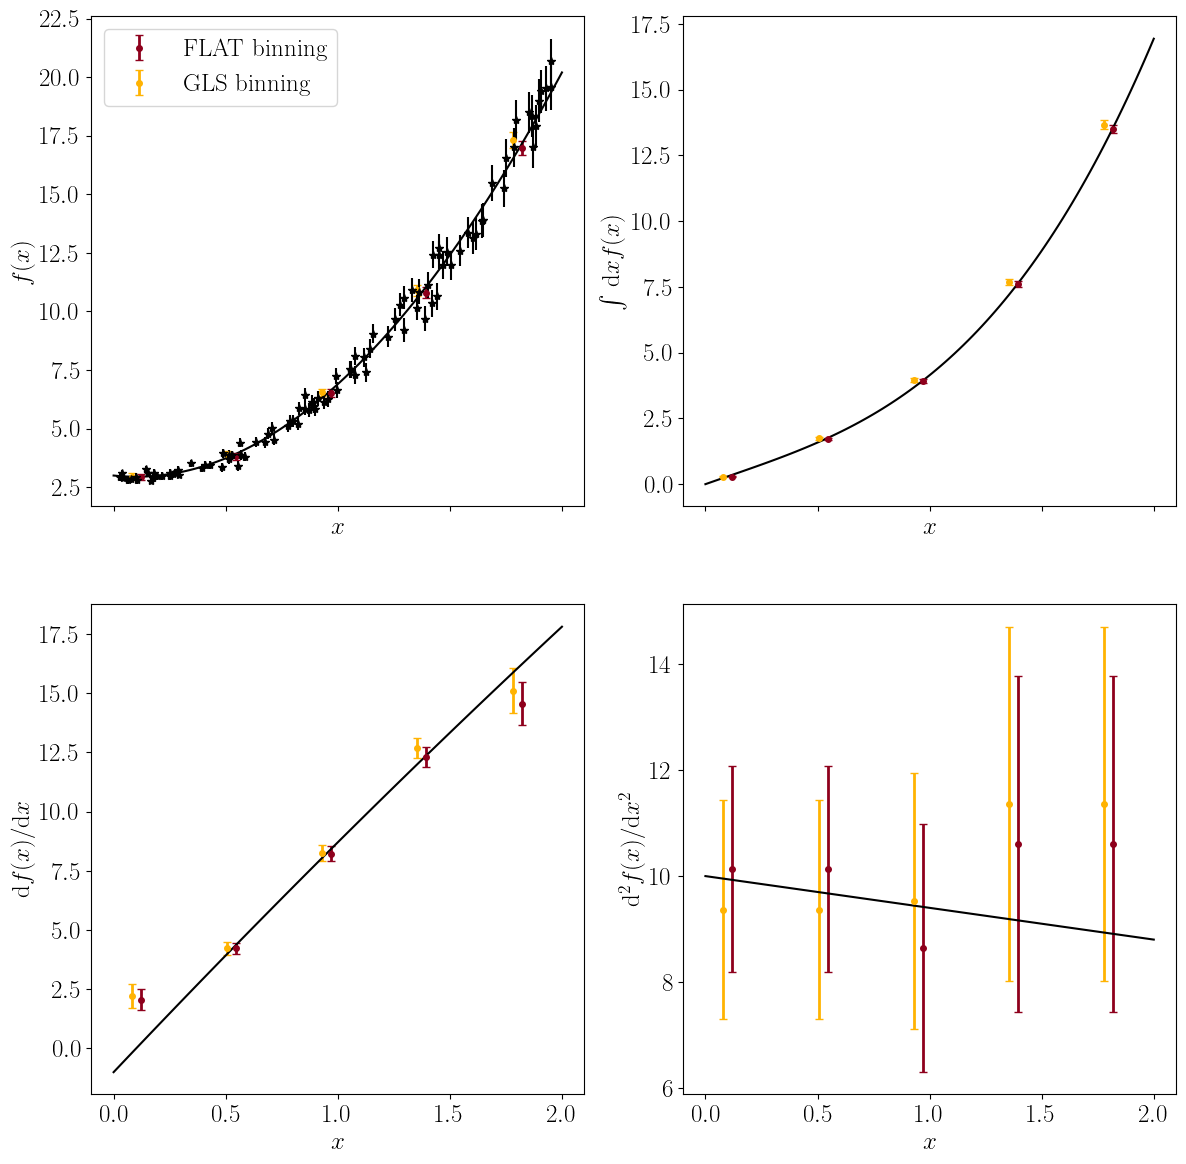

In [16]:
xplot = np.linspace(xmin,xmax,100)
x_shift = 0.02
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = y_label
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int$ d'+x_label+''+y_label
    elif ind == 2:
        i = 1
        j = 0
        label = r'd'+y_label+'/d'+x_label
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2$'+y_label+'/d'+x_label+r'$^2$'

    m = 0
    for name,recon in binning_results.items():
        df = recon['final_df']
        axes[i,j].errorbar(df['x']+x_shift*(-1)**m,df[deriv],yerr=df[deriv+'_err'],ls='',color=colors[m],alpha=1,
                           fmt='o',ms=4,capsize=3,elinewidth=2.0,label=name+' binning')
        m += 1
        
    axes[i,j].plot(xplot,theory_model[deriv](xplot),color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv],yerr=dataset[deriv+'_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(x_label)
    axes[i,j].set_ylabel(label)
axes[0,0].legend(loc='best');

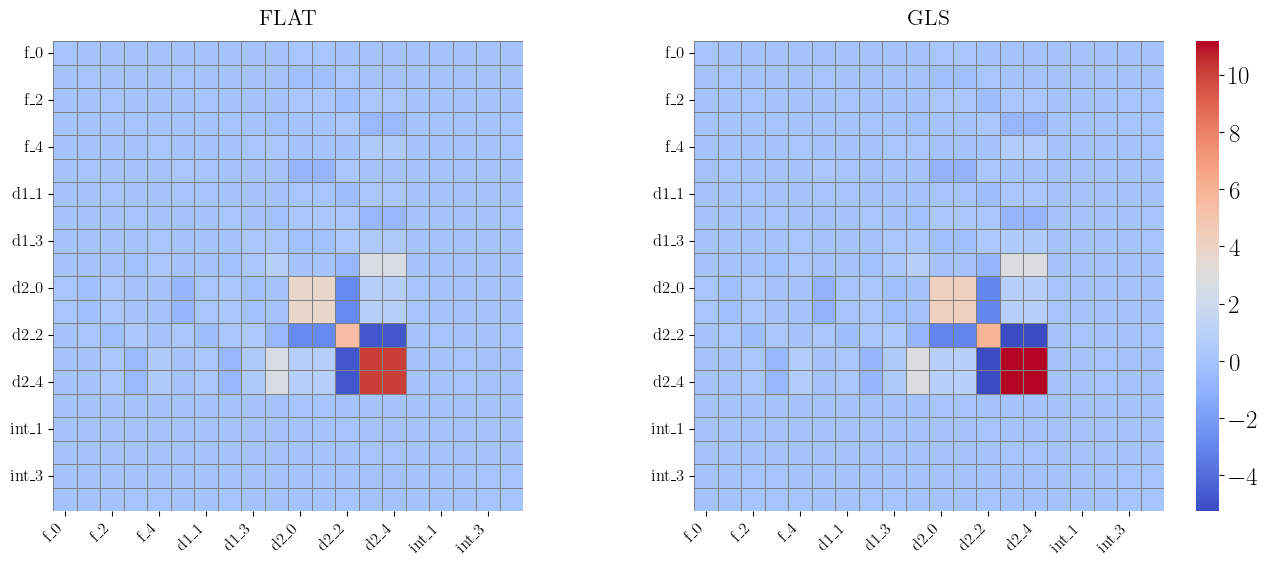

In [17]:
# 1. Compute the global min and max across both dataframes for unified scaling
vmin = min(binning_results['FLAT']['final_covmat'].values.min(), binning_results['GLS']['final_covmat'].values.min())
vmax = max(binning_results['FLAT']['final_covmat'].values.max(), binning_results['GLS']['final_covmat'].values.max())

# 2. Setup the layout grid: 
# 1 row, 3 columns (Plot 1, Plot 2, and a narrow column for the shared colorbar)
fig, axes = plt.subplots(nrows=1,ncols=2,figsize=(14, 6))

i = 0
for name,recon in binning_results.items():
    if i == 1:
        cbar = True
    else:
        cbar = False
    df = recon['final_covmat']
    sb.heatmap(df,ax=axes[i],vmin=vmin,vmax=vmax,cmap="coolwarm",linewidths=0.5,linecolor="gray",cbar=cbar,square=True,)
    axes[i].set_title(name, fontsize=16, pad=12)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha="right", fontsize=12)
    axes[i].set_yticklabels(axes[i].get_yticklabels(), rotation=0, fontsize=12)
    i += 1

# 5. Fine-tune space parameters and save
plt.tight_layout()

# Diagnostics

In [18]:
from CoRe.utils.diagnostics import Scorer

In [19]:
score = {}

In [20]:
for k,v in binning_results.items():
    score[k] = Scorer(v['final_df'],v['final_covmat'],chatty=True)

## Mahalanobis score

In [21]:
theory_df = pd.DataFrame({'x': x_recon}|{func: theory_model[func](x_recon) for func in ['f','d1','d2','int']})

In [22]:
for k,v in score.items():
    print('')
    print(k)
    res = v.score_against_theory(theory_df)


FLAT

 SCORE REPORT: THEORY CONSISTENCY
Status (Full System): POOR (Significant Tension)
Full Total Chi2:      703025378047.93
Full Red.  Chi2:      35151268902.397
Full P-value:         0.0000
Full DOF:             20

Eigenmode Spectrum Breakdown (Sorted by Eigenvalue / Variance Descending):
Mode ID   | Eigenvalue (Var) | Chi2 Contrib  | Percentage | Status  
---------------------------------------------------------------------------
Mode 0    | 2.42e+01         | 0.18          |   0.0%     | ACTIVE
Mode 1    | 9.01e+00         | 0.00          |   0.0%     | ACTIVE
Mode 2    | 1.48e+00         | 0.44          |   0.0%     | ACTIVE
Mode 3    | 1.58e-01         | 1.33          |   0.0%     | ACTIVE
Mode 4    | 5.41e-02         | 0.38          |   0.0%     | ACTIVE
Mode 5    | 1.00e-11         | 804491354.37  |   0.1%     | ACTIVE
Mode 6    | 1.00e-11         | 19262320995.57 |   2.7%     | ACTIVE
Mode 7    | 1.00e-11         | 170190348869.62 |  24.2%     | ACTIVE
Mode 8    | 1.00e-11

## Pointwise $\chi^2$ Scoring

In [23]:
for k,v in score.items():
    print('')
    print(k)
    res = v.score_pointwise(theory_df)


FLAT

 SCORE REPORT: POINTWISE THEORY CONSISTENCY
Status (Full System): MARGINAL (High Tension)
Full Total Chi2:      35.20
Full Red.  Chi2:      1.760
Full P-value:         0.0191
Full DOF:             20

Pointwise Component Breakdown:
  - f    :     0.43 (  1.2%)
  - d1   :    24.88 ( 70.7%)
  - d2   :     0.66 (  1.9%)
  - int  :     9.23 ( 26.2%)


GLS

 SCORE REPORT: POINTWISE THEORY CONSISTENCY
Status (Full System): POOR (Significant Tension)
Full Total Chi2:      41.93
Full Red.  Chi2:      2.096
Full P-value:         0.0028
Full DOF:             20

Pointwise Component Breakdown:
  - f    :     2.88 (  6.9%)
  - d1   :    21.74 ( 51.8%)
  - d2   :     1.07 (  2.6%)
  - int  :    16.24 ( 38.7%)



## Scoring Against Data (Consistency)

In [24]:
datasets = [{'type': 'f',
             'df': dataset,
             'cov': covmat}]

In [25]:
for k,v in score.items():
    print('')
    print(k)
    res = v.score_against_data(datasets)


FLAT

 SCORE REPORT: EXTERNAL DATA VALIDATION
Status (Full System): POOR (Significant Tension)
Full Total Chi2:      141.69
Full Red.  Chi2:      1.417
Full P-value:         0.0039
Full DOF:             100

Eigenmode Spectrum Breakdown (Sorted by Eigenvalue / Variance Descending):
Mode ID   | Eigenvalue (Var) | Chi2 Contrib  | Percentage | Status  
---------------------------------------------------------------------------
Mode 0    | 3.38e+00         | 0.41          |   0.3%     | ACTIVE
Mode 1    | 2.18e+00         | 1.83          |   1.3%     | ACTIVE
Mode 2    | 1.93e+00         | 0.53          |   0.4%     | ACTIVE
Mode 3    | 1.92e+00         | 2.06          |   1.5%     | ACTIVE
Mode 4    | 1.88e+00         | 1.76          |   1.2%     | ACTIVE
Mode 5    | 1.85e+00         | 0.80          |   0.6%     | ACTIVE
Mode 6    | 1.83e+00         | 2.34          |   1.7%     | ACTIVE
Mode 7    | 1.81e+00         | 1.49          |   1.1%     | ACTIVE
Mode 8    | 1.79e+00         | 0.10

# Binned reconstruction for correlated data

**blablabla**

In [26]:
Ndata   = 100
xmin    = 0
xmax    = 2
err_fac = 5

x_label = r'$x$'
y_label = r'$f(x)$'

method = 'GLS'

In [27]:
fiducial_func1 = {'a0': 3,
                  'a1': -1}

theory_func_1 = get_theory(list(fiducial_func1.values()))

In [28]:
fiducial_func2 = {'a0': 3,
                  'a1': -1,
                  'a2': 5}

theory_func_2 = get_theory(list(fiducial_func2.values()))

**DATA FORMAT FOR CORRELATED DATA**

In order to work with GP on correlated functions, the dataset should be provide as a DataFrame containing the columns

`x, f1, f2`

while the covariance should have as columns (and index)

`f1_0 ... f1_N, f2_0 ... f2_N`

with $N$ the number of data points.

In [29]:
dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})

thvals = theory_func_1['f'](dataset['x'])
errors = abs(thvals)*err_fac/100
dataset['f1'] = np.random.normal(thvals,errors)
dataset['f1_err'] = errors

thvals = theory_func_2['f'](dataset['x'])
errors = abs(thvals)*err_fac/100
dataset['f2'] = np.random.normal(thvals,errors)
dataset['f2_err'] = errors

dataset['r(f1,f2)'] = np.random.uniform(0.5,1,len(dataset))
dataset

,x,f1,f1_err,f2,f2_err,"r(f1,f2)"
0,1.958592,1.144701,0.052070,19.100093,1.011091,0.685637
1,0.558032,2.631154,0.122098,3.911458,0.199948,0.528027
2,0.717595,2.240999,0.114120,4.969950,0.242856,0.950877
3,1.428057,1.580291,0.078597,12.582626,0.588434,0.599871
4,0.504104,2.472246,0.124795,3.966637,0.188325,0.592003
...,...,...,...,...,...,...
95,0.878453,2.148753,0.106077,6.222757,0.298997,0.935748
96,1.817427,1.138907,0.059129,17.448227,0.884889,0.840511
97,1.378533,1.663558,0.081073,11.924792,0.556162,0.949980
98,0.830619,2.238135,0.108469,5.351833,0.280951,0.691785


In [30]:
covmat_1 = pd.DataFrame(np.diag(errors*2),columns=['f1_{}'.format(ind) for ind in range(len(dataset['x']))])
covmat_1.index = covmat_1.columns

covmat_2 = pd.DataFrame(np.diag(errors*2),columns=['f2_{}'.format(ind) for ind in range(len(dataset['x']))])
covmat_2.index = covmat_2.columns

cov_cross = np.diag([row['f1_err']*row['f2_err']*row['r(f1,f2)'] for ind,row in dataset.iterrows()])

joint_matrix = np.block([[covmat_1.values,  cov_cross],
                         [cov_cross.T, covmat_2.values]])

N = len(dataset)
labels = [f"f1_{i}" for i in range(N)] + [f"f2_{i}" for i in range(N)]
covmat = pd.DataFrame(joint_matrix, columns=labels, index=labels)

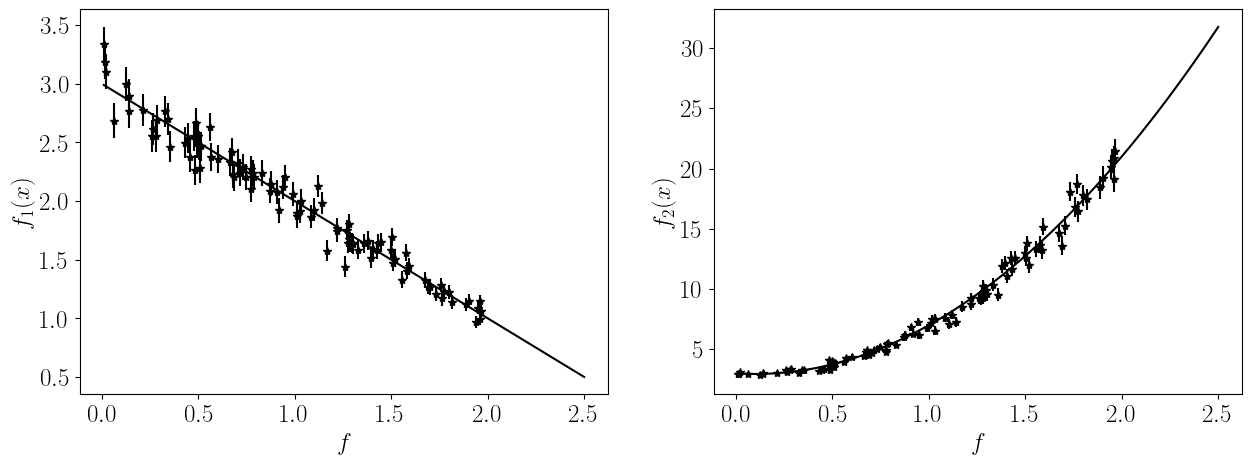

In [31]:
xplot = np.linspace(0.01,2.5,100)

fig,axes = plt.subplots(nrows=1,ncols=2,sharey=False,sharex=True,figsize=(15,5))

axes[0].plot(xplot,theory_func_1['f'](xplot),color='black')
axes[0].errorbar(dataset['x'],dataset['f1'],yerr=dataset['f1_err'],color='black',ls='',marker='*')
axes[0].set_xlabel(r'$f$')
axes[0].set_ylabel(r'$f_1(x)$')

axes[1].plot(xplot,theory_func_2['f'](xplot),color='black')
axes[1].errorbar(dataset['x'],dataset['f2'],yerr=dataset['f2_err'],color='black',ls='',marker='*')
axes[1].set_xlabel(r'$f$')
axes[1].set_ylabel(r'$f_2(x)$');

In [32]:
reconstructions = {}

## Uncorrelated reconstruction

In [33]:
dataset_1 = dataset.copy()
dataset_1 = dataset_1[['x','f1','f1_err']].rename(columns={'f1': 'f','f1_err': 'f_err'})
covmat_1.columns = ['f_'+str(i) for i in range(len(covmat_1.columns))]
covmat_1.index   = ['f_'+str(i) for i in range(len(covmat_1.columns))]

bin_engine = BinnedCalculator(dataset_1,covmat_1,method=method)
means,joint_cov,mask = bin_engine.reconstruct(x_recon,fiducial=theory_func_1['f'])

reconstructions['Func1'] = {'Functions': means,
                            'Covmat': joint_cov}

  [value] well-covered bins: [0, 1, 2, 3, 4]
  [value] WARNING: edge optimization did NOT converge in 50 iters (max |x_eff - x_new| = 2.01e-02)


In [34]:
dataset_2 = dataset.copy()
dataset_2 = dataset_2[['x','f2','f2_err']].rename(columns={'f2': 'f','f2_err': 'f_err'})
covmat_2.columns = ['f_'+str(i) for i in range(len(covmat_2.columns))]
covmat_2.index   = ['f_'+str(i) for i in range(len(covmat_2.columns))]

bin_engine = BinnedCalculator(dataset_2,covmat_2,method=method)
means,joint_cov,mask = bin_engine.reconstruct(x_recon,fiducial=theory_func_1['f'])

reconstructions['Func2'] = {'Functions': means,
                            'Covmat': joint_cov}

  [value] well-covered bins: [0, 1, 2, 3, 4]
  [value] WARNING: edge optimization did NOT converge in 50 iters (max |x_eff - x_new| = 2.01e-02)


## Correlated reconstruction

In [35]:
dataset = dataset.drop(columns=['r(f1,f2)'])

bin_engine = BinnedCalculator(dataset,covmat,method=method)
means,joint_cov,mask = bin_engine.reconstruct(x_recon,fiducial=[theory_func_1['f'],theory_func_2['f']])

reconstructions['Correlated'] = {'Functions': means,
                                 'Covmat': joint_cov}

  [value] well-covered bins: [0, 1, 2, 3, 4]
  [value] WARNING: edge optimization did NOT converge in 50 iters (max |x_eff - x_new| = 2.01e-02)


## Plotting

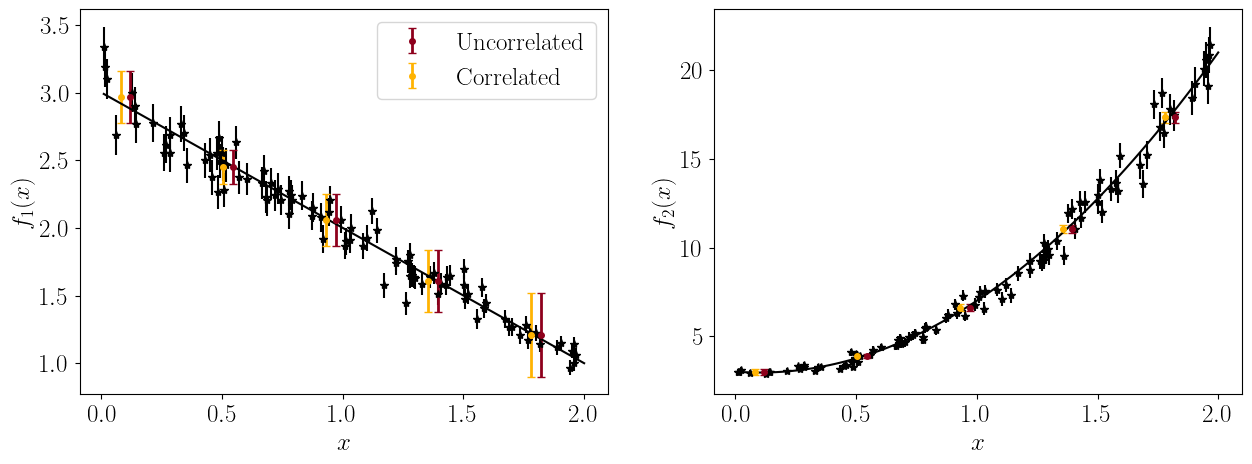

In [36]:
xplot = np.linspace(0.01,2.,100)
xshift = 0.02

fig,axes = plt.subplots(nrows=1,ncols=2,sharey=False,sharex=True,figsize=(15,5))
axes[0].errorbar(dataset['x'],dataset['f1'],yerr=dataset['f1_err'],color='black',ls='',marker='*')
df =  reconstructions['Func1']['Functions']
axes[0].errorbar(df['x']+xshift,df['f'],yerr=df['f_err'],ls='',color=red,alpha=1,
                 fmt='o',ms=4,capsize=3,elinewidth=2.0,label='Uncorrelated')
df =  reconstructions['Correlated']['Functions']
axes[0].errorbar(df['x']-xshift,df['f1'],yerr=df['f1_err'],ls='',color=yellow,alpha=1,
                 fmt='o',ms=4,capsize=3,elinewidth=2.0,label='Correlated')
axes[0].plot(xplot,theory_func_1['f'](xplot),color='black')
axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r'$f_1(x)$')
axes[0].legend(loc='best')



df =  reconstructions['Func2']['Functions']
axes[1].errorbar(dataset['x'],dataset['f2'],yerr=dataset['f2_err'],color='black',ls='',marker='*')
axes[1].errorbar(df['x']+xshift,df['f'],yerr=df['f_err'],ls='',color=red,alpha=1,
                 fmt='o',ms=4,capsize=3,elinewidth=2.0,label='Uncorrelated')
df =  reconstructions['Correlated']['Functions']
axes[1].errorbar(df['x']-xshift,df['f2'],yerr=df['f2_err'],ls='',color=yellow,alpha=1,
                 fmt='o',ms=4,capsize=3,elinewidth=2.0,label='Correlated')
axes[1].plot(xplot,theory_func_2['f'](xplot),color='black')
axes[1].set_xlabel(r'$x$')
axes[1].set_ylabel(r'$f_2(x)$');